# Constraint experiments

Shared data and architecture; separate cells for none, soft, and hard constraints.
## DONT TAKE THIS TOO SERIOUSLY YET IDK WHY THE ERROR RATES ARE SO HIGH

In [1]:
%pip install -q numpy matplotlib pandas torch scikit-image


Note: you may need to restart the kernel to use updated packages.


In [2]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

DATA = Path("data/bunny_cross_sections.npz")
TRAIN_RES = 32
STEPS = 8
BASE_CHANNELS = 4
LEARNING_RATE = 2e-3
TRUNCATION = 0.1
SEED = 11
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_num_threads(max(1, min(8, torch.get_num_threads())))
print(DEVICE)

cpu


## Data

In [3]:
with np.load(DATA) as archive:
    target = torch.from_numpy(archive["sdf3d"].astype(np.float32))[None, None]
    observed_mask = torch.from_numpy(archive["observed_mask"].astype(np.float32))[None, None]
    observed_sdf2d = torch.from_numpy(archive["observed_sdf2d"].astype(np.float32))[None, None]
    observed_normal = torch.from_numpy(archive["observed_normal"].astype(np.float32))[None]
    u_obs = torch.from_numpy(archive["u_obs"].astype(np.float32))[None, None]

source_res = target.shape[-1]
if source_res != TRAIN_RES:
    size = (TRAIN_RES,) * 3
    target = F.interpolate(target, size=size, mode="trilinear", align_corners=True)
    observed_sdf2d = F.interpolate(observed_sdf2d, size=size, mode="trilinear", align_corners=True)
    observed_normal = F.interpolate(observed_normal, size=size, mode="trilinear", align_corners=True)
    u_obs = F.interpolate(u_obs, size=size, mode="trilinear", align_corners=True)
    if source_res % TRAIN_RES == 0:
        factor = source_res // TRAIN_RES
        observed_mask = F.max_pool3d(observed_mask, factor, factor)
    else:
        observed_mask = F.interpolate(observed_mask, size=size, mode="nearest")

observed_sdf2d *= observed_mask
observed_normal *= observed_mask
inputs = torch.cat((observed_mask, observed_sdf2d, observed_normal, u_obs), dim=1)

inputs = inputs.to(DEVICE)
target = target.to(DEVICE)
observed_mask = observed_mask.bool().to(DEVICE)
observed_sdf2d = observed_sdf2d.to(DEVICE)
u_obs = u_obs.to(DEVICE)

spacing = 2.0 / (TRAIN_RES - 1)
print({"input": tuple(inputs.shape), "target": tuple(target.shape), "observed_voxels": int(observed_mask.sum())})

{'input': (1, 6, 32, 32, 32), 'target': (1, 1, 32, 32, 32), 'observed_voxels': 7173}


## Shared model, losses, and metrics

In [4]:
class Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        groups = min(4, out_channels)
        self.layers = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
            nn.Conv3d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.layers(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=6, base=4):
        super().__init__()
        self.enc1 = Block(in_channels, base)
        self.enc2 = Block(base, 2 * base)
        self.bridge = Block(2 * base, 4 * base)
        self.pool = nn.MaxPool3d(2)
        self.up2 = nn.ConvTranspose3d(4 * base, 2 * base, 2, stride=2)
        self.dec2 = Block(4 * base, 2 * base)
        self.up1 = nn.ConvTranspose3d(2 * base, base, 2, stride=2)
        self.dec1 = Block(2 * base, base)
        self.out = nn.Conv3d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        bridge = self.bridge(self.pool(e2))
        d2 = self.dec2(torch.cat((self.up2(bridge), e2), dim=1))
        d1 = self.dec1(torch.cat((self.up1(d2), e1), dim=1))
        return self.out(d1)


def truncated_l1(prediction, truth, truncation=TRUNCATION):
    prediction = prediction.clamp(-truncation, truncation)
    truth = truth.clamp(-truncation, truncation)
    return F.l1_loss(prediction, truth)


def slice_bound_loss(prediction):
    excess = F.relu(prediction.abs() - observed_sdf2d.abs())
    return excess[observed_mask].mean()


def section_sign_loss(prediction):
    sign = torch.where(observed_sdf2d < 0, -1.0, 1.0)
    return F.softplus(-sign * prediction / 0.02)[observed_mask].mean()


def eikonal_loss(prediction):
    dx = torch.diff(prediction, dim=2)[:, :, :, :-1, :-1] / spacing
    dy = torch.diff(prediction, dim=3)[:, :, :-1, :, :-1] / spacing
    dz = torch.diff(prediction, dim=4)[:, :, :-1, :-1, :] / spacing
    gradient_norm = torch.sqrt(dx.square() + dy.square() + dz.square() + 1e-8)
    return (gradient_norm - 1).square().mean()


@dataclass(frozen=True)
class Experiment:
    name: str
    constraint: str
    bound_weight: float = 0.0
    section_weight: float = 0.0
    eikonal_weight: float = 0.0


def constrained_output(raw, constraint):
    if constraint == "hard":
        return u_obs * torch.tanh(raw)
    return raw


def run_experiment(config):
    torch.manual_seed(SEED)
    model = UNet3D(inputs.shape[1], BASE_CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []
    for step in range(STEPS):
        optimizer.zero_grad()
        prediction = constrained_output(model(inputs), config.constraint)
        terms = {"sdf": truncated_l1(prediction, target)}
        if config.bound_weight:
            terms["bound"] = slice_bound_loss(prediction)
        if config.section_weight:
            terms["section"] = section_sign_loss(prediction)
        if config.eikonal_weight:
            terms["eikonal"] = eikonal_loss(prediction)
        loss = terms["sdf"]
        loss = loss + config.bound_weight * terms.get("bound", 0.0)
        loss = loss + config.section_weight * terms.get("section", 0.0)
        loss = loss + config.eikonal_weight * terms.get("eikonal", 0.0)
        loss.backward()
        optimizer.step()
        history.append({key: float(value.detach()) for key, value in {"total": loss, **terms}.items()})
    model.eval()
    with torch.no_grad():
        prediction = constrained_output(model(inputs), config.constraint)
    return {"config": config, "model": model, "prediction": prediction.detach(), "history": history}


def metrics(prediction):
    slice_excess = F.relu(prediction.abs() - observed_sdf2d.abs())[observed_mask]
    hard_excess = F.relu(prediction.abs() - u_obs)
    predicted_inside = prediction < 0
    true_inside = target < 0
    intersection = (predicted_inside & true_inside).sum()
    union = (predicted_inside | true_inside).sum().clamp_min(1)
    near_surface = target.abs() < 2 * spacing
    return {
        "mae": float(F.l1_loss(prediction, target)),
        "surface_mae": float((prediction - target).abs()[near_surface].mean()),
        "iou": float(intersection / union),
        "slice_slab_excess": float(slice_excess.mean()),
        "slice_slab_violation_rate": float((slice_excess > 1e-5).float().mean()),
        "contour_envelope_max": float(hard_excess.max()),
    }


results = {}

## No constraint

In [5]:
results["none"] = run_experiment(Experiment("none", "none"))
results["none"]["history"][-1]

{'total': 0.06607034802436829, 'sdf': 0.06607034802436829}

## Soft plane bound

In [6]:
results["soft"] = run_experiment(Experiment("soft", "soft", bound_weight=2.0))
results["soft"]["history"][-1]

{'total': 0.14743922650814056,
 'sdf': 0.11994561553001404,
 'bound': 0.013746804557740688}

## Hard contour envelope

In [7]:
results["hard"] = run_experiment(Experiment("hard", "hard"))
results["hard"]["history"][-1]

{'total': 0.058416977524757385, 'sdf': 0.058416977524757385}

## Evaluation

In [8]:
summary = pd.DataFrame({name: metrics(result["prediction"]) for name, result in results.items()}).T
summary

,mae,surface_mae,iou,slice_slab_excess,slice_slab_violation_rate,contour_envelope_max
none,0.372470,0.525877,0.302113,0.323839,0.779451,1.571999
soft,0.425855,0.116934,0.084235,0.011437,0.261536,1.544816
hard,0.247139,0.083611,0.299087,0.030780,0.493796,0.000000


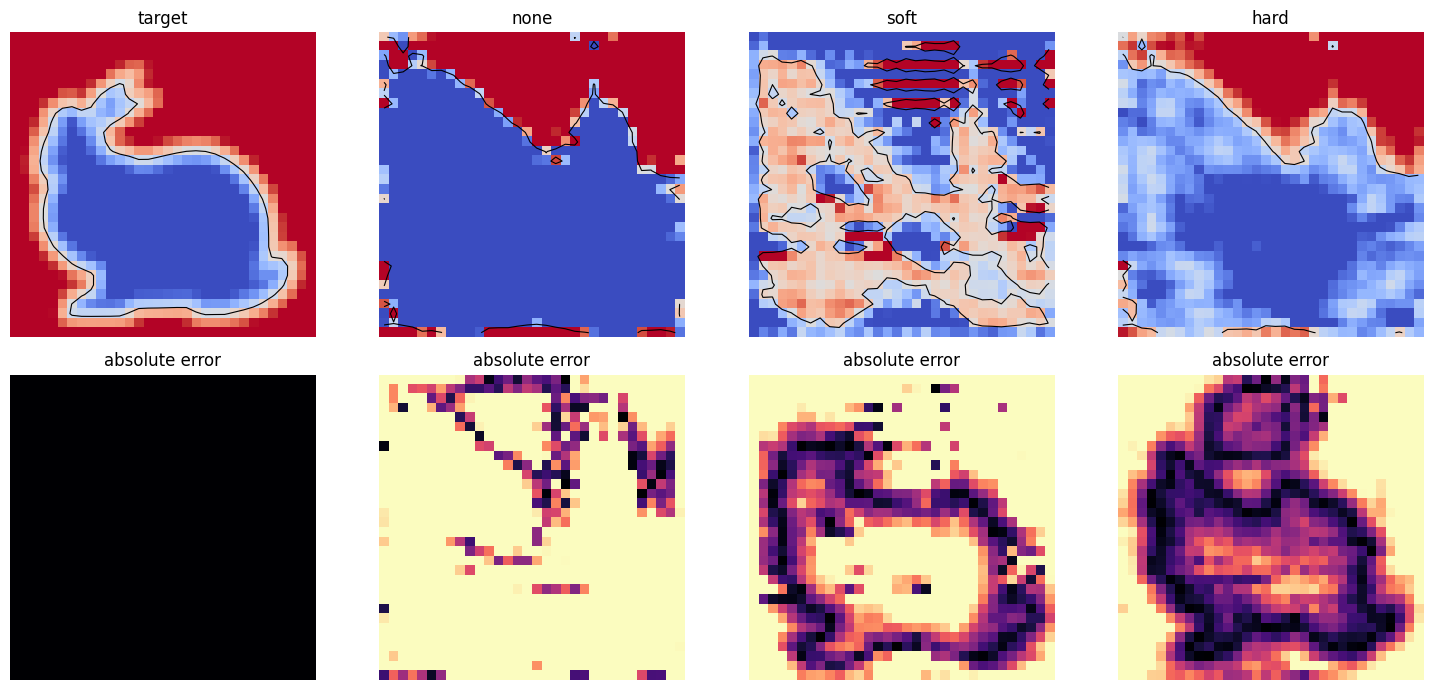

In [9]:
middle = TRAIN_RES // 2
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fields = {"target": target, **{name: result["prediction"] for name, result in results.items()}}

for column, (name, field) in enumerate(fields.items()):
    image = field[0, 0, :, :, middle].detach().cpu().T
    axes[0, column].imshow(image, origin="lower", cmap="coolwarm", vmin=-TRUNCATION, vmax=TRUNCATION)
    axes[0, column].contour(image, levels=[0], colors="black", linewidths=0.8)
    axes[0, column].set_title(name)
    error = (field - target).abs()[0, 0, :, :, middle].detach().cpu().T
    axes[1, column].imshow(error, origin="lower", cmap="magma", vmin=0, vmax=0.2)
    axes[1, column].set_title("absolute error")
    axes[0, column].set_axis_off()
    axes[1, column].set_axis_off()

fig.tight_layout()
plt.show()

## Save results

In [10]:
output_dir = Path("data")
output_dir.mkdir(exist_ok=True)
summary.to_csv(output_dir / "constraint_metrics.csv")
np.savez_compressed(
    output_dir / f"constraint_predictions_{TRAIN_RES}.npz",
    target=target.detach().cpu().numpy(),
    none=results["none"]["prediction"].cpu().numpy(),
    soft=results["soft"]["prediction"].cpu().numpy(),
    hard=results["hard"]["prediction"].cpu().numpy(),
)